# Random Forests y redshifts fotométricos

En este notebook, se usa el algoritmo de random forest para estimar redshifts fotométricos a partir de observaciones de galaxias en 6 filtros diferentes  (u, g, r, i, z, y).

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

Trataremos de reproducir los resultados este [este paper](https://arxiv.org/abs/1903.08174)

Este ejercicio es introductorio y complementario a la clase de Métodos de Ensemble. Usaremos una versión simplificada de catálogo DEEP2 de redshift. 

Este notebook está pensado para que **predigas antes de correr el código**, y para que respondas las preguntas de reflexión en base a lo visto en la clase de Ensemble Methods.

## Setup y limpieza mínima

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from astropy.io import fits
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

data=pd.read_csv('redshift_ejemplo_RF.csv')
data

,u_apercor,g_apercor,r_apercor,i_apercor,z_apercor,y_apercor,zhelio
0,24.362068,24.136913,23.490342,22.777181,22.319676,22.100980,0.957669
1,23.552186,23.420734,23.010863,22.550723,22.277656,21.860866,0.909043
2,23.983330,24.104438,23.461145,23.359428,22.929944,22.690175,0.502974
3,24.665840,24.408938,23.544115,23.155140,22.706477,22.894691,0.649839
4,23.518039,22.746858,21.571629,20.645176,20.428926,20.306110,0.679440
...,...,...,...,...,...,...,...
8503,24.455093,24.275983,24.233811,24.109624,23.809521,23.389464,1.473057
8504,23.461026,23.007713,22.359102,21.553143,20.946282,20.972074,0.990994
8505,24.615031,22.985132,21.601458,21.027322,20.732666,20.588093,0.370325
8506,22.611269,22.080842,21.404755,21.188319,20.962956,20.998884,0.370973


In [2]:
cols = ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'z_apercor', 'y_apercor']
X = data[cols]
y = data['zhelio'].values

### Visualicemos rápidamente las bandas fotométricas vs. el redshift

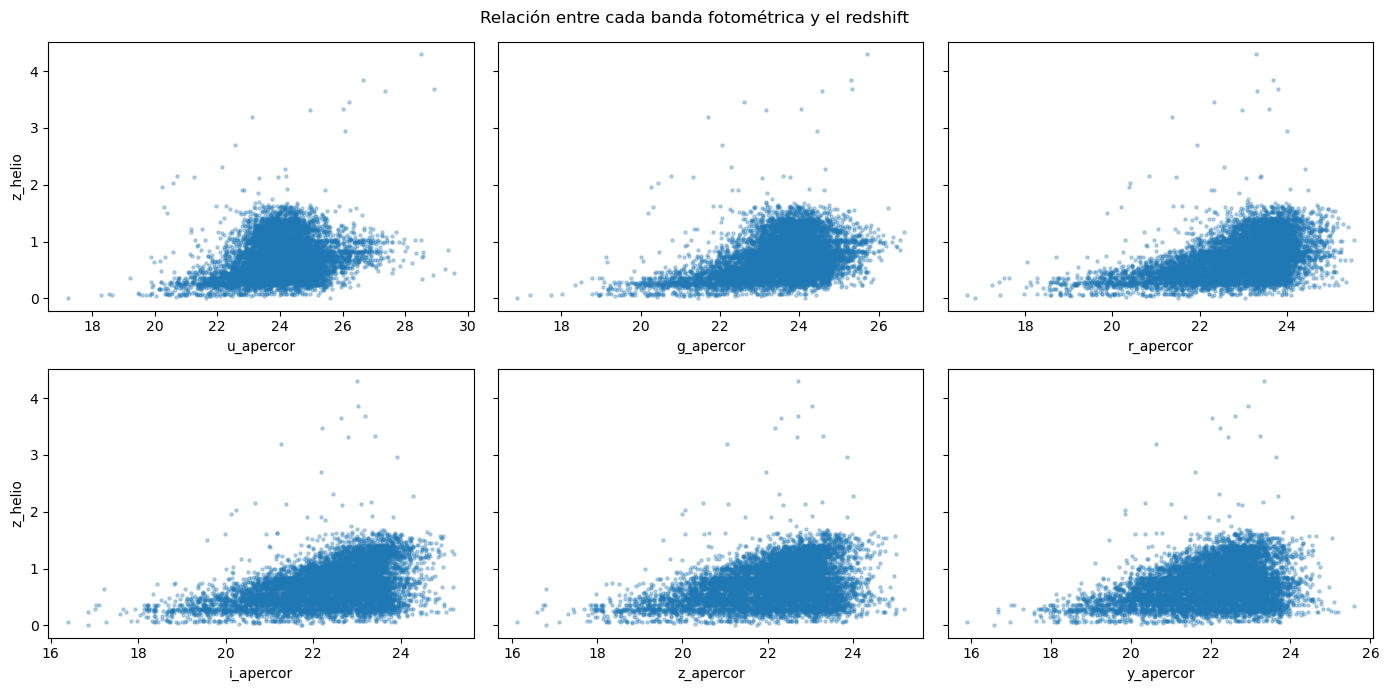

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, col in zip(axes.flat, cols):
    ax.scatter(X[col], y, s=5, alpha=0.3)
    ax.set_xlabel(col)
axes[0, 0].set_ylabel('z_helio')
axes[1, 0].set_ylabel('z_helio')
plt.suptitle('Relación entre cada banda fotométrica y el redshift')
plt.tight_layout()
plt.show()

**Pregunta previa:** mirando estos 6 gráficos, ¿Alguna banda individual parece más informativa que otras para predecir el redshift?  Explique

Ninguna banda individual luce más informativa que otras, todas tienen distribuciones similares.

## Parte 1: Bootstrap a mano

Antes de correr el código: si toma una muestra bootstrap (con reemplazo) del mismo tamaño que tu dataset original, ¿qué fracción de las galaxias originales espera que **no** aparezca ni una sola vez en esa muestra?

Espero que un 37% de los datos originales no aparezcan ni una sola vez.

In [16]:
n = len(X)
idx = np.random.choice(n, n, replace=True)

fraccion_unica = len(np.unique(idx)) / n
print(f"Fracción de galaxias únicas en la muestra bootstrap: {fraccion_unica:.3f}")
print(f"Fracción OOB (fuera de esta muestra): {1 - fraccion_unica:.3f}")

Fracción de galaxias únicas en la muestra bootstrap: 0.624
Fracción OOB (fuera de esta muestra): 0.376


**Preguntas de reflexión:**

1. ¿El valor de "fracción OOB" que obtuvo se parece al ~37% que vimos en clase? ¿A qué límite matemático converge cuando $N \to \infty$?


    Se parece al 37%, y la combinatoria hacia infinito converge a $e^{-1} \approx 36$ 
2. Si usara `replace=False` en vez de `True`, ¿qué pasaría con esta fracción? ¿Por qué bagging necesita específicamente muestreo *con* reemplazo?

La fracción sería 0, porque se vería obligado a tomar todos los datos eventualmente. Necesitamos que las muestras sean completamente aleatorias e independientes entre sí, para que los procesos sean paralelos y no sesgados.

### Bootstrap con Random Forest

El bootstrap que acabamos de hacer "a mano" es exactamente lo que `RandomForestRegressor` hace internamente para **cada uno** de sus árboles, de forma automática. Puedes verlo en sus parámetros:

```python
rf_ejemplo = RandomForestRegressor(n_estimators=200)
print(rf_ejemplo.get_params()['bootstrap'])  # True por defecto
```

Cuando entrenamos un Random Forest con `n_estimators=200`, internamente arma 200 muestras bootstrap distintas (una por árbol) exactamente como hicimos arriba, entrena un árbol en cada una, y guarda cuáles observaciones quedaron "fuera de la bolsa" (OOB) para cada árbol

In [6]:
rf_ejemplo = RandomForestRegressor(n_estimators=200)
print(rf_ejemplo.get_params()['bootstrap'])  # True por defecto


True


## Parte 2: Un árbol de decisión vs. Random Forest

Antes de correr el código: vamos a entrenar un árbol de decisión sin restricción de profundidad, y un Random Forest de 200 árboles, cada uno 20 veces con distintas particiones train/test. ¿Cuál de los dos espera que tenga predicciones más *variables* de una partición a otra?

#### ShuffleSplit
Para ver qué tan *variable* es el desempeño de un modelo, necesitamos repetir el experimento de entrenar/evaluar muchas veces con particiones distintas, y mirar cuánto cambia el resultado de una repetición a otra.

`ShuffleSplit(n_splits=20, test_size=0.3)` genera 20 particiones aleatorias independientes (70% train / 30% test cada una), y `cross_val_score` se encarga de entrenar y evaluar el modelo en cada una automáticamente. 

En el boxplot podemos ver qué tan dispersos son los resultados de cada modelo. 



In [7]:
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=20, test_size=0.3, random_state=0)

scores_arbol = cross_val_score(
    DecisionTreeRegressor(random_state=0), X, y,
    cv=cv, scoring='neg_mean_squared_error'
)
scores_rf = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=0), X, y,
    cv=cv, scoring='neg_mean_squared_error'
)

mse_arbol = -scores_arbol
mse_rf = -scores_rf

print(f"Árbol único, MSE promedio: {mse_arbol.mean():.4f}, desviación estándar: {mse_arbol.std():.4f}")
print(f"Random Forest, MSE promedio: {mse_rf.mean():.4f}, desviación estándar: {mse_rf.std():.4f}")

Árbol único, MSE promedio: 0.0545, desviación estándar: 0.0074
Random Forest, MSE promedio: 0.0283, desviación estándar: 0.0042


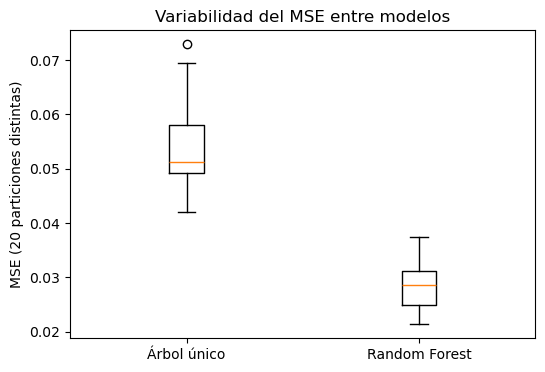

In [8]:
plt.figure(figsize=(6, 4))
plt.boxplot([mse_arbol, mse_rf], tick_labels=['Árbol único', 'Random Forest'])
plt.ylabel('MSE (20 particiones distintas)')
plt.title('Variabilidad del MSE entre modelos')
plt.show()

**Preguntas de reflexión:**

1. ¿Cuál modelo tiene mayor variabilidad (desviación estándar) del MSE entre las 20 particiones distintas? ¿Coincide con su predicción inicial?
El árbol único, esto coincide con mi predicción inicial.

2. Según la fórmula $\text{Var}_{\rm ensemble}(x) = \rho(x)\sigma^2(x) + \frac{1-\rho(x)}{M}\sigma^2(x)$ que vimos en clase, ¿qué término está bajando acá al promediar 20 árboles?

    El segundo término $\frac{1-\rho(x)}{M}\sigma^2(x)$
3. ¿Esperaría que el *bias* del Random Forest sea muy distinto al del árbol único? ¿Por qué sí o por qué no?

No esperaría que sea muy distinto, porque al tomar muestras aleatorias debería mantenerse representativo.

## Parte 3: OOB error vs. Cross-Validation

Antes de correr el código: OOB usa las galaxias que quedaron fuera de cada bootstrap para validar, sin necesitar un split explícito. ¿Espera que el error OOB sea parecido al de una validación cruzada de 5 folds, o sistemáticamente distinto?

Son funcionalmente similares, así que no espero difieran mucho.

In [9]:
rf = RandomForestRegressor(n_estimators=200, oob_score=True, random_state=0)
rf.fit(X, y)
print(f"OOB R²: {rf.oob_score_:.3f}")

cv_scores = cross_val_score(RandomForestRegressor(n_estimators=200, random_state=0), X, y, cv=5)
print(f"Cross-validation R² (5-fold): {np.mean(cv_scores):.3f}")

OOB R²: 0.769
Cross-validation R² (5-fold): 0.765


**Preguntas de reflexión:**

1. ¿Los dos valores de $R^2$ son parecidos? ¿Esperabas que lo fueran?

    Son parecidos, esperaba que las métricas fueran similares porque son pruebas de calidad con motivaciones similares.

2. ¿Qué ventaja práctica tiene OOB frente a hacer 5-fold CV, en términos de tiempo de cómputo, considerando que aquí trabajamos con miles de galaxias?


    OOB es significativamente más rápido porque sólo trabajamos con una submuestra de los datos totales, en cambio 5-fold separa toda la muestra y trabaja con cada uno de los subsamples.
3. ¿En qué situación NO confiaría en el error OOB como estimador confiable del error de test? (pista: piensa en si las galaxias del catálogo son verdaderamente independientes entre sí, o si podría haber estructura espacial/de agrupamiento, por ejemplo galaxias del mismo cúmulo).


Cuando los elementos que quedan OOB están más relacionados entre sí que con los que se entrenó al modelo, y por lo tanto este no tiene información de como manejarlo.

## Parte 4: Feature Importance

Antes de correr el código: mirando el gráfico de la Parte 0 (bandas vs. redshift), ¿qué banda(s) espera que resulten más importantes? Quizá la banda u, con una agrupación de forma circular.

r_apercor    0.369078
u_apercor    0.188421
i_apercor    0.133171
y_apercor    0.120177
z_apercor    0.098871
g_apercor    0.090282
dtype: float64


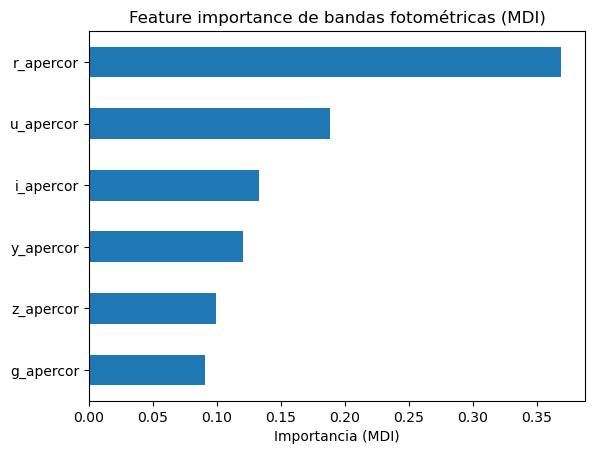

In [10]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias)

importancias.plot(kind='barh')
plt.xlabel('Importancia (MDI)')
plt.title('Feature importance de bandas fotométricas (MDI)')
plt.gca().invert_yaxis()
plt.show()

### ¿MDI es confiable, o está sesgado hacia bandas más ruidosas?

Si observa el scatter plot de la Parte 0, notará que `u_apercor` tiene el rango de magnitudes más amplio y la nube de puntos más dispersa de las 6 bandas. El **Mean Decrease Impurity (MDI)** es conocido en la literatura (Strobl et al. 2007) por estar sesgado a favor de variables con mayor rango/variabilidad, simplemente porque le dan al árbol más posibles puntos de split, no necesariamente porque sean más informativas.

**Hipótesis a verificar:** ¿la posición alta de `u_apercor` en el ranking de MDI es un artefacto de este sesgo, o es una importancia genuina?

Para responder esto hay que comparar contra un criterio distinto, menos sensible a esta fuente de sesgo: la **permutation importance**, que mide directamente cuánto empeora el modelo si desordena aleatoriamente una columna.

r_apercor    1.687512
u_apercor    0.834474
i_apercor    0.518406
y_apercor    0.452200
g_apercor    0.373816
z_apercor    0.275869
dtype: float64


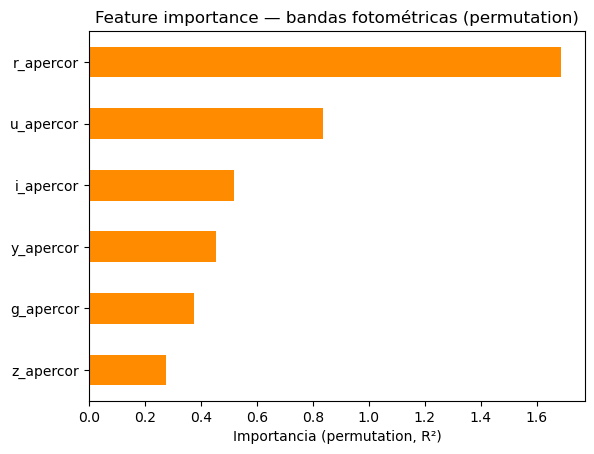

In [15]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X, y, n_repeats=10, random_state=0, scoring='r2')

importancias_perm = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print(importancias_perm)

importancias_perm.plot(kind='barh', color='darkorange')
plt.xlabel('Importancia (permutation, R²)')
plt.title('Feature importance — bandas fotométricas (permutation)')
plt.gca().invert_yaxis()
plt.show()

**Preguntas de reflexión:**

1. Compare el orden de las 6 bandas entre MDI y permutation importance. ¿`u_apercor` se mantiene en una posición alta en ambos criterios, o cae notoriamente en permutation? ¿Qué le dice eso sobre la hipótesis del sesgo de MDI en este caso particular?

    Se mantiene en una posición alta, esto nos dice que el MDI no está sesgado y que `u_apercor` es realmente relevante.
2. Si ambos criterios coinciden en el ranking, ¿qué explicación física alternativa se le ocurre para que una banda con mediciones más ruidosas siga siendo muy informativa? (pista: piense en el 4000A break y en qué banda cae esa discontinuidad espectral para distintos rangos de redshift).

    Se me ocurre que el 4000 A break se ve principalmente en la banda U para los redshifts que estamos estudiando.
3. Si repitiera este análisis con Gradient Boosting en vez de Random Forest, ¿esperaría el mismo ranking?

    No exactamente, _Boosting_ priorizaría las variables con menos dispersión según mi entendimiento.
4. Si una banda tuviera importancia muy baja en ambos criterios, ¿la eliminaría del modelo sin más análisis, o
qué verificaría primero?

Comenzaría buscando una explicación física, porque quizá la banda no nos otorga mucha información a los modelos, pero tiene mucha relevancia en el contexto del problema.

## Parte 5:Esquema completo: optimización, predicción y métricas

Hasta ahora usamos un Random Forest con hiperparámetros por defecto. En esta parte armamos el flujo completo búsqueda de hiperparámetros con `GridSearchCV`, generación de predicciones para todo el dataset, y las métricas que reporta el paper que reproduce el notebook de clase.

**Antes de correr el código:** ¿espera que optimizar hiperparámetros mejore mucho el $R^2$ respecto al modelo por defecto, o solo un poco? Solo un poco, aunque a veces la selección de features aumenta el $R^2$ sin real mejora.

In [11]:
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict

parameters = {
    'max_depth': [3, 6, None],
    'max_features': [None, 4, 2],
    'n_estimators': [50, 100, 200],
    'min_samples_leaf': [1, 5, 10],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=5),
    parameters,
    cv=KFold(n_splits=5, shuffle=True, random_state=10),
    n_jobs=4,
    verbose=1,
)
grid.fit(X, y)

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor score (CV, R²): {grid.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejores hiperparámetros: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor score (CV, R²): 0.7698


### Predicciones con el mejor modelo

Usamos `cross_val_predict` para generar una predicción de $z$ para **cada** galaxia del dataset, pero siempre usando un modelo que no la vio durante su entrenamiento. Comparamos $z_{\rm true}$ vs. $z_{\rm pred}$ 

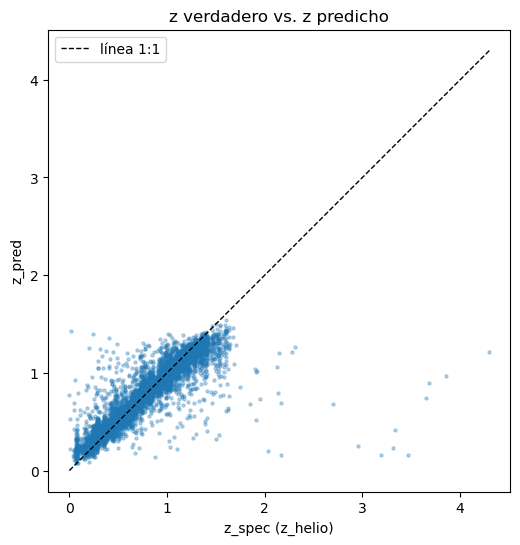

In [12]:
best_model = grid.best_estimator_

y_pred = cross_val_predict(best_model, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=10))

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, s=5, alpha=0.3)
plt.plot([0, y.max()], [0, y.max()], 'k--', lw=1, label='línea 1:1')
plt.xlabel('z_spec (z_helio)')
plt.ylabel('z_pred')
plt.axis('square')
plt.legend()
plt.title('z verdadero vs. z predicho')
plt.show()

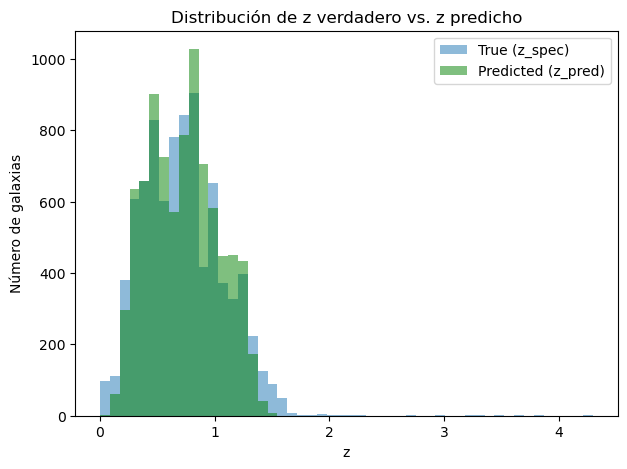

In [13]:
plt.figure(figsize=(7, 5))
plt.hist(y, bins=50, density=False, alpha=0.5, range=(0, y.max()), label='True (z_spec)')
plt.hist(y_pred, bins=50, density=False, alpha=0.5, range=(0, y.max()), color='g', label='Predicted (z_pred)')
plt.xlabel('z')
plt.ylabel('Número de galaxias')
plt.legend()
plt.title('Distribución de z verdadero vs. z predicho')
plt.show()

### ¿Por qué la distribución predicha se ve más angosta que la real?

la distribución de `z_pred` (verde) tiende a ser más
angosta que la de `z_spec` (azul): pierde las colas altas y bajas de la
distribución real. Esto no es un error de tu modelo en particular; es una
característica estructural de **todos** los métodos basados en árboles.

**La razón:** un árbol de regresión predice, para cualquier observación nueva,
el **promedio del target de todos los puntos de entrenamiento que cayeron en la
misma hoja**. Si una galaxia tiene un redshift muy alto (raro en el catálogo),
sus "vecinas" en el espacio de features probablemente tienen redshifts más
moderados, así que la hoja que le toca termina prediciendo un promedio más bajo
que su valor real. Lo mismo ocurre en el otro extremo: una galaxia con z muy
bajo cae en una hoja junto a vecinas de z algo más alto, y su predicción queda
sobreestimada.

Este efecto se repite en todas las observaciones extremas del dataset, y el
resultado es que el histograma completo de predicciones se "encoge" hacia el
centro sistemáticamente subestimando los valores altos y sobreestimando los
bajos. Promediar muchos árboles (como hace Random Forest) no corrige este efecto;
de hecho, promediar promedios tiende a acentuarlo un poco más.


**Preguntas de reflexión:**

1. ¿El scatter se ve razonablemente cerca de la línea 1:1, o hay una desviación sistemática en algún rango de $z$?

    Hay una desviación sistemática en z entre 0 y 1.
2. ¿Se ve el efecto de estrechez en el scatter plot? ¿En qué extremo del rango de $z$ se nota más?

Se nota un poco en el extremo superior.

### Métricas MSE, $\sigma_{\rm NMAD}$ y fracción de outliers

Además del MSE, se reportan otras dos métricas

- **$\sigma_{\rm NMAD}$** (normalized median absolute deviation): una medida robusta de dispersión de los residuos, poco sensible a outliers. El residuo normalizado es 

$$
\Delta z_i = \frac{z_{{\rm spec},i} - z_{{\rm pred},i}}{1 + z_{{\rm spec},i}}
$$

La dispersión robusta de los residuos es la normalized median absolute deviation:

$$
\sigma_{\rm NMAD} = 1.48 \times {\rm median}\left(
\left| \Delta z_i - {\rm median}(\Delta z) \right|
\right)
$$

- **$\eta$** (fracción de outliers): la proporción de galaxias cuyo residuo normalizado supera 0.15.
$$
\frac{|z_{\rm spec} - z_{\rm pred}|}{1 + z_{\rm spec}} > 0.15
$$

In [17]:
mse = np.mean((y - y_pred)**2)

delta_z = (y - y_pred) / (1 + y)
sigma_nmad = 1.48 * np.median(np.abs(delta_z - np.median(delta_z)))
eta_outliers = np.mean(np.abs(delta_z) > 0.15)

print(f"MSE: {mse:.4f}")
print(f"sigma_NMAD: {sigma_nmad:.4f}")
print(f"Fracción de outliers (eta): {eta_outliers:.4f}")

MSE: 0.0292
sigma_NMAD: 0.0375
Fracción de outliers (eta): 0.0528


**Preguntas de reflexión:**

1. Compare tus valores de $\sigma_{\rm NMAD}$ y $\eta$ con los que obtiene el paper. ¿Está cerca, lejos, mejor o peor? ¿A qué le atribuye la diferencia, si la hay? 


    Son peores que los valores para el _CFHTLS Deep Field_, pero son mejores que los valores para el _CFHTLS Wide Field_, atribuyo la diferencia principalmente a que mi muestra de datos no tiene distinción entre ambos y por lo tanto los resultados con una combinación de ambos campos. Seguramente hay diferencias sutiles en los hiperparámetros.
    
2. $\sigma_{\rm NMAD}$ usa la mediana en vez del promedio para medir dispersión. ¿Por qué esto la hace más robusta frente a outliers que, por ejemplo, la desviación estándar de $\Delta z$? 

    La mediana es, por definición, una medida estadística mucho más robusta frente a los outliers.
3. Si su $\eta$ (fracción de outliers) es alto, ¿qué haría primero: cambiar de modelo, agregar más features, o revisar la calidad de los datos de entrada? Justifique su prioridad.

Comenzaría revisando los datos de entrada, si estos son muy dispersos, ningún modelo podrá evitar el efecto de los outliers.


## Cierre: Tarea 2

Acá usamos un subset de juguete. En la **Tarea 2** va a tener que decidir usted mismo/a los filtros de calidad, qué hacer con datos faltantes o anómalos, y posiblemente construir nuevas features.

La pregunta será **"¿qué decisiones debo tomar yo antes de que el método pueda funcionar bien?"**